# Introduction

This project aims to answer whether school performance, measured by average ACT scores, is predicted by socioeconomic factors. These factors include median income, employment rate, percentage of students receiving free and reduced-price lunch, and student teacher ratios. This notebook, in particular, analyzes these factors to identify relationships among the variables and derive correlations.

## Sources

https://www.edgap.org/#5/37.719/-96.899

https://data-nces.opendata.arcgis.com/datasets/43b42be85c4749e48267f83f1f6ffa60_0/explore?location=32.339121%2C-96.020508%2C4.46&showTable=true

https://www.dropbox.com/scl/fi/o8wf1f534pb4u7uavgjxm/ccd_sch_029_1617_w_1a_11212017.csv?rlkey=k2aey38xie2vz9ge4a0v3rrib&e=1&dl=0

#Import libraries

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library built on matplotlib
import seaborn as sns
# set the plotting style
sns.set_style("whitegrid")

# Model preprocessing
from sklearn.preprocessing import StandardScaler

# Modeling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Model metrics and analysis
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.anova import anova_lm

# Load Clean Data

In [2]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/naomi-rlm/Education/main/data/education_clean.csv'
)

# Exploratory Data Analysis

## Examine distributions and relationships

Plot the correlation matrix of the numerical variables in the training data to explore relationships between the variables.

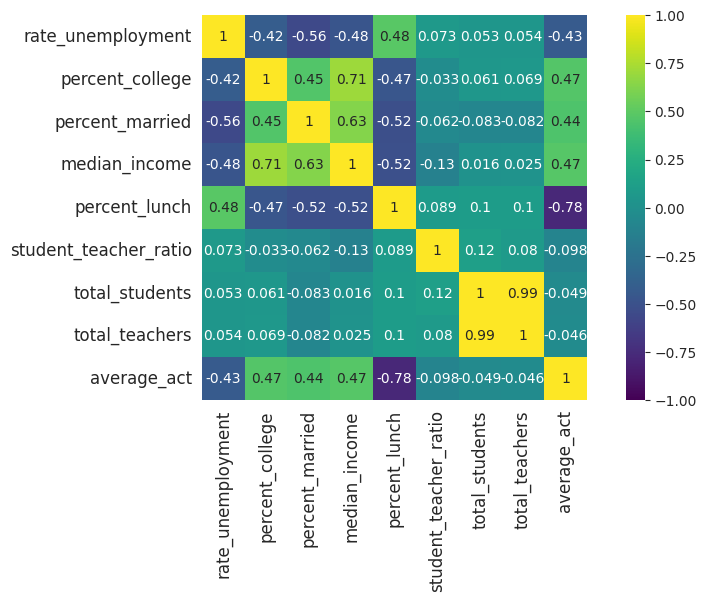

In [3]:
# Build a correlation heatmap for EDA

# Select numeric predictors and append the target
predictor_variables = ['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 'percent_lunch', 'state', 'charter', 'student_teacher_ratio','total_students', 'total_teachers']

numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

# Compute the Pearson correlation matrix.
corr_matrix = df[numerical_predictors + ["average_act"]].corr()

# Plot as a square, annotated heatmap (values clipped to [-1, 1]) using the viridis colormap.
# Larger figure and tick labels improve readability
plt.figure(figsize=(10, 5))

sns.heatmap(
    corr_matrix, vmax=1, vmin=-1, square=True, annot=True, cmap="viridis"
)

plt.tick_params(labelsize=12)

plt.show()

### Make pair plots to explore relationships between the variables



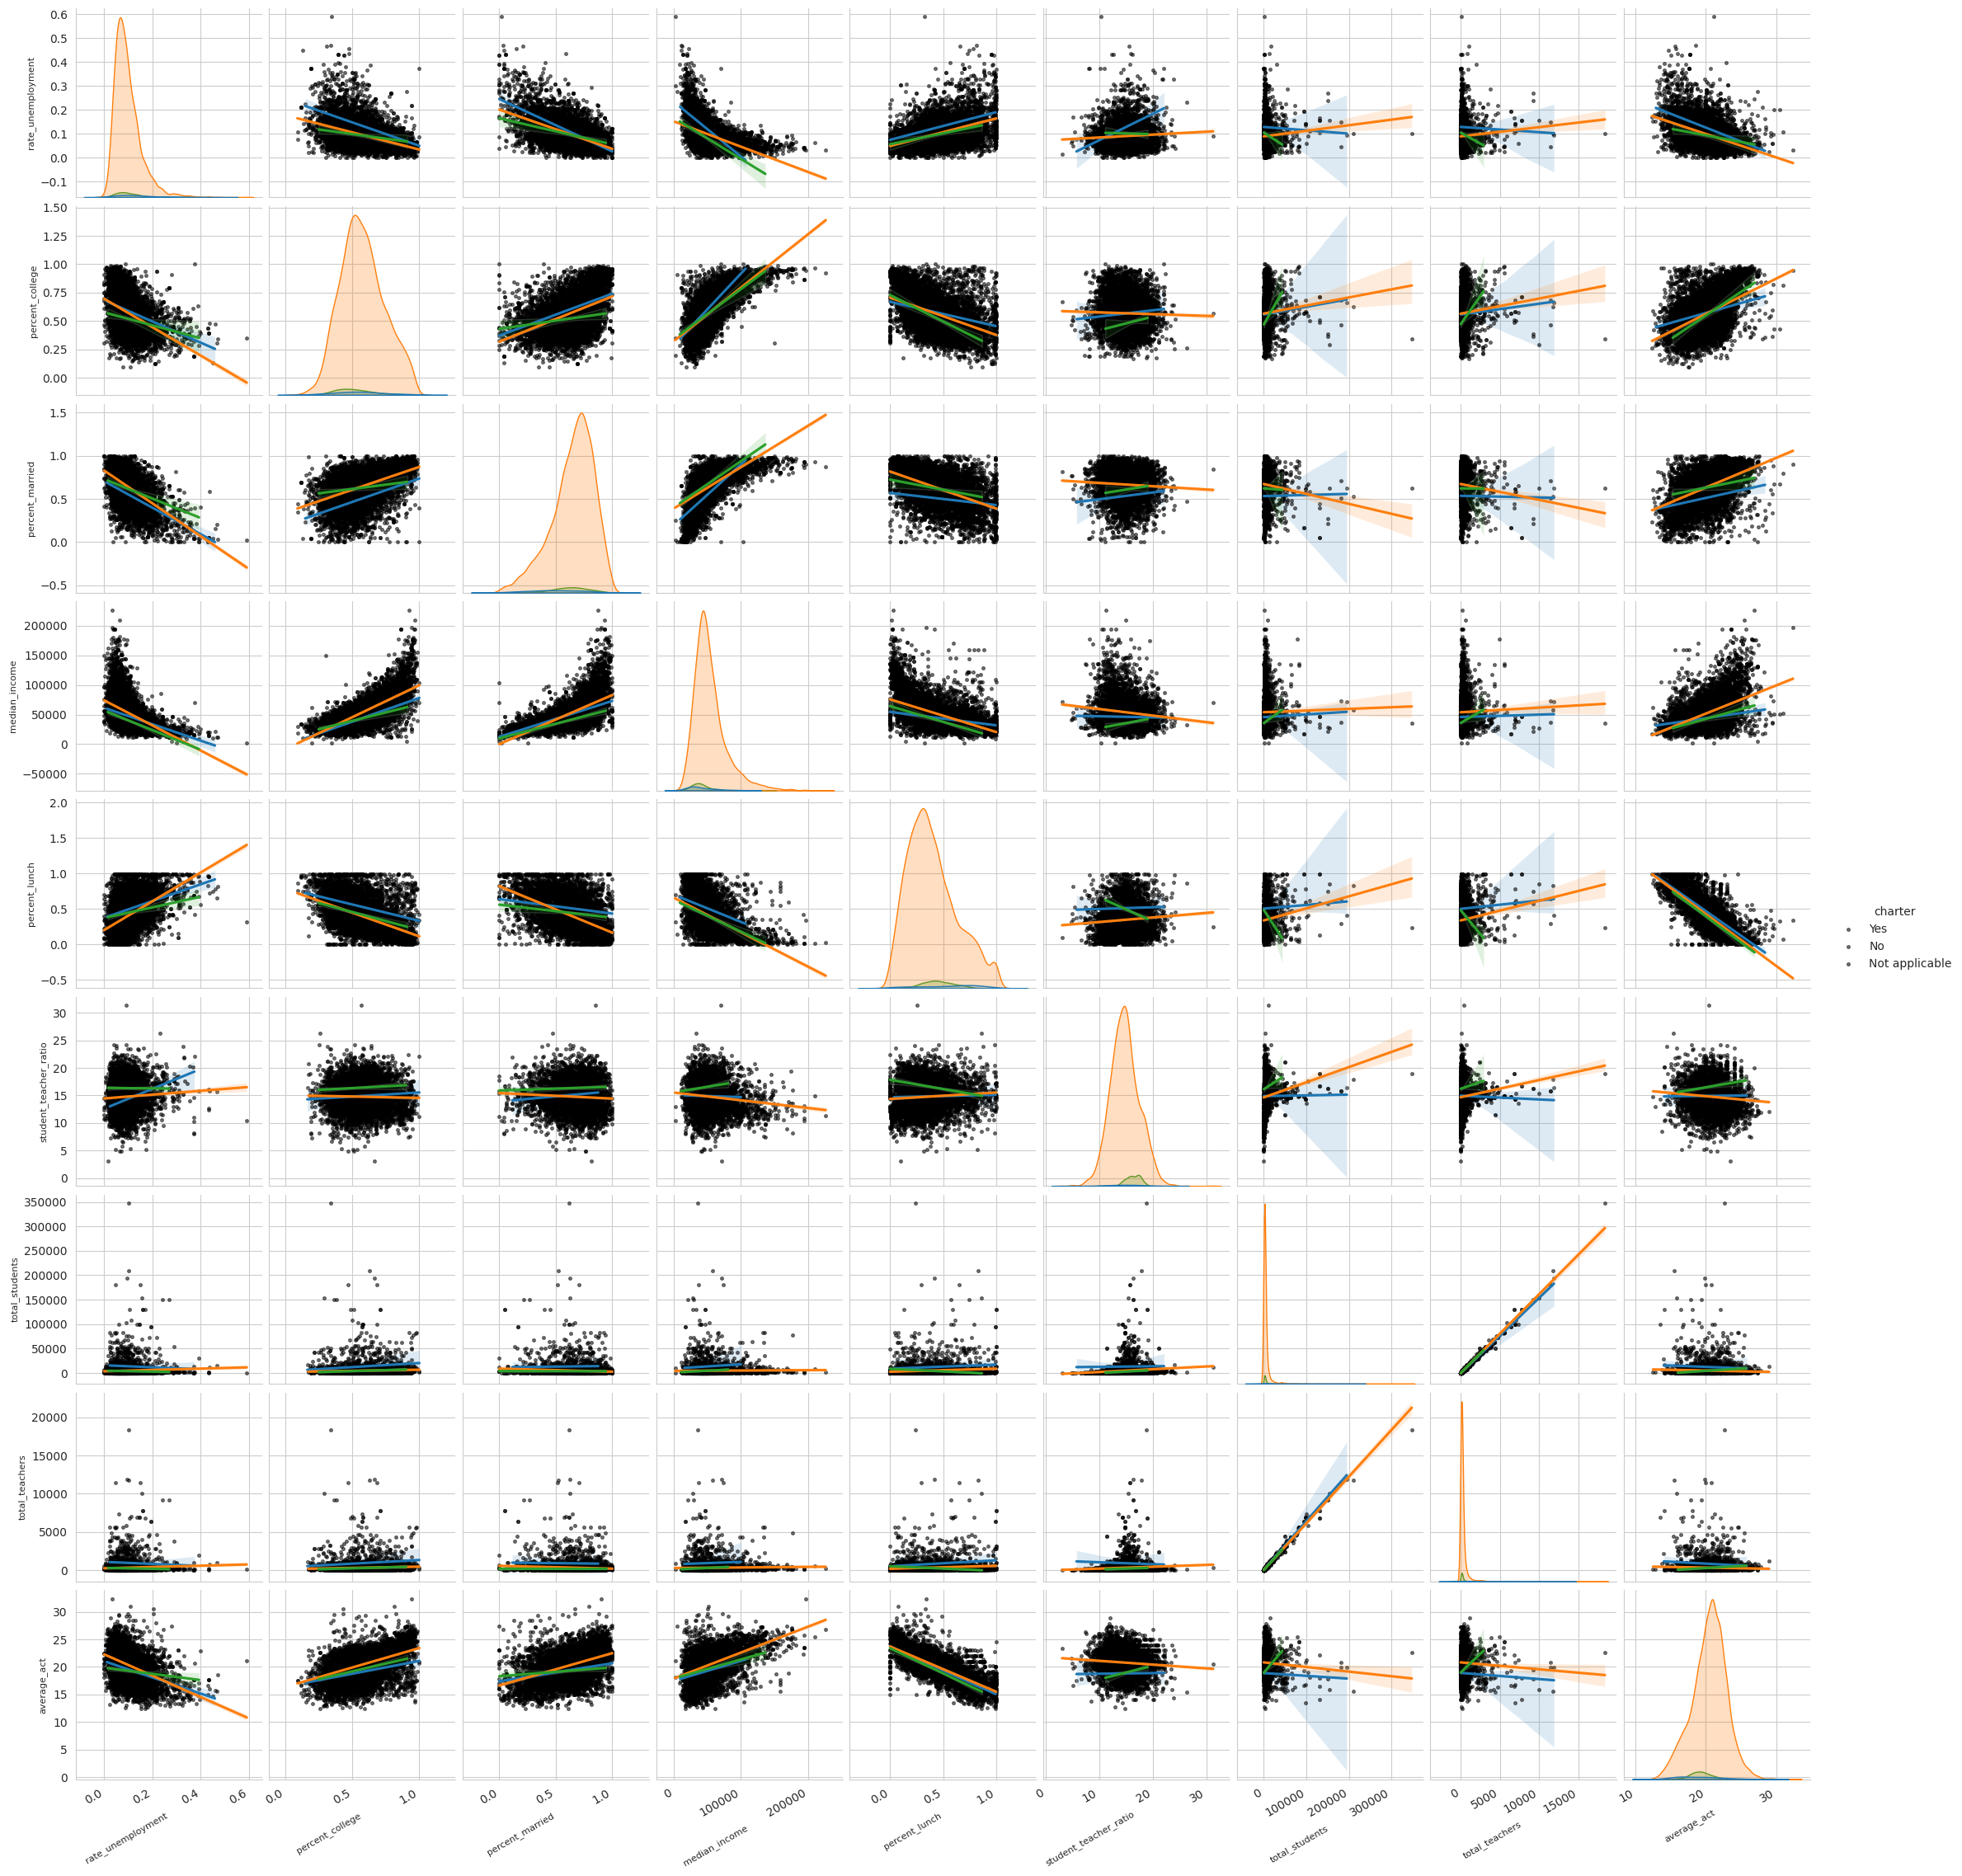

In [4]:
# Pair plot to explore relationships between predictors and the target,
# with regression lines and color by charter status

fig = sns.pairplot(
    data=df,
    vars=numerical_predictors + ['average_act'],
    hue='charter',
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

# Post-format axes for readability
for ax in fig.axes.flat:
    # If this axis uses the CT income field, format x-ticks in scientific notation
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

## Identify outliers

 Use the interquartile range to identify outliers. Median income and student teacher ratio are on a very different scale than the other predictors, so need three plots to explore the data.

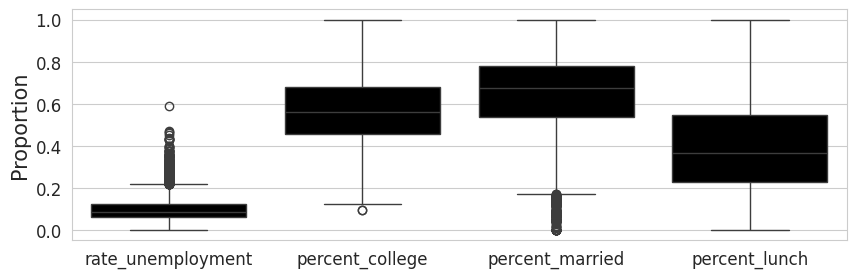

In [5]:
# Boxplots to spot outliers among proportion-like predictors

plt.figure(figsize=(10,3))

# Start from all numeric predictors, then drop variables on very different scales
# so the y-axis is comparable across plots.
fractions = list(numerical_predictors)
for col in ['median_income', 'total_students', 'total_teachers', 'student_teacher_ratio']:
    if col in fractions:
        fractions.remove(col)

# Draw boxplots for the remaining variables
sns.boxplot(data=df[fractions], color='k')

plt.ylabel('Proportion', fontsize=15)

plt.tick_params(labelsize=12)

plt.show()

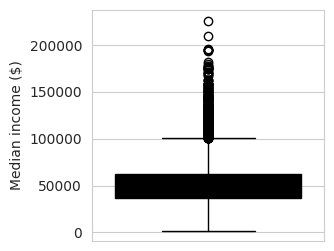

In [6]:
# Boxplot to inspect outliers and spread for median household income
plt.figure(figsize=(3,3))

sns.boxplot(data=df, y='median_income', color='k')

plt.ylabel('Median income ($)')

plt.show()

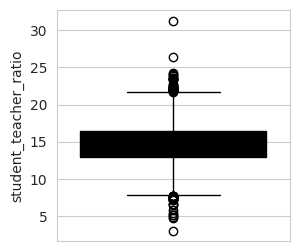

In [7]:
# Boxplot to inspect outliers and spread for student–teacher ratios
plt.figure(figsize=(3,3))

sns.boxplot(data=df, y='student_teacher_ratio', color='k')

plt.ylabel('student_teacher_ratio')

plt.show()

## Single input models

Fit and assess models predicting the average ACT score from each of the input variables.

### Median income

Plot the regression line and the scatter plot

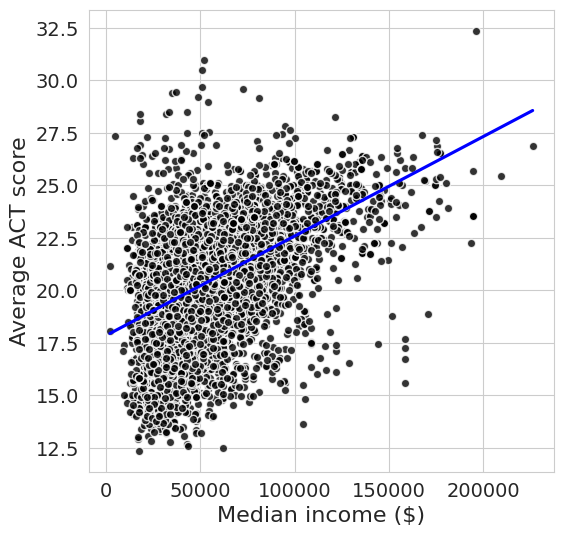

In [8]:
# Simple linear model visualization, ACT vs. median income
plt.figure(figsize=(6, 6))

sns.regplot(data=df,
            x='median_income',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Median income ($)', fontsize=16)
plt.ylabel('Average ACT score', fontsize=16)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize=14)

plt.show()

#### Fit the simple linear regression model

In [9]:
# Fit a simple regression predicting average ACT score from median income
model_median_income = smf.ols(formula='average_act ~ median_income', data=df).fit()

#### Display the fit summary: check the sign and significance of the coefficients

In [10]:
print(model_median_income.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.223
Method:                 Least Squares   F-statistic:                     2342.
Date:                Thu, 23 Oct 2025   Prob (F-statistic):               0.00
Time:                        04:29:32   Log-Likelihood:                -17987.
No. Observations:                8182   AIC:                         3.598e+04
Df Residuals:                    8180   BIC:                         3.599e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        17.8507      0.057    311.843

#### Numerical assessment of fit accuracy

Compute the R-squared

In [11]:
# R-squared: proportion of variance in ACT explained by median_income
model_median_income.rsquared


np.float64(0.22259653575994331)

Compute the RMSE

In [12]:
# RMSE: typical prediction error
y_hat = model_median_income.predict()

In [13]:
np.sqrt(mean_squared_error(df['average_act'], y_hat)).round(3)

np.float64(2.18)

Compute the mean absolute error

In [14]:
# MAE: average absolute prediction error
mean_absolute_error(df['average_act'], y_hat)

1.6755079938705537

#### Use a residual plot for graphical assessment of model fit

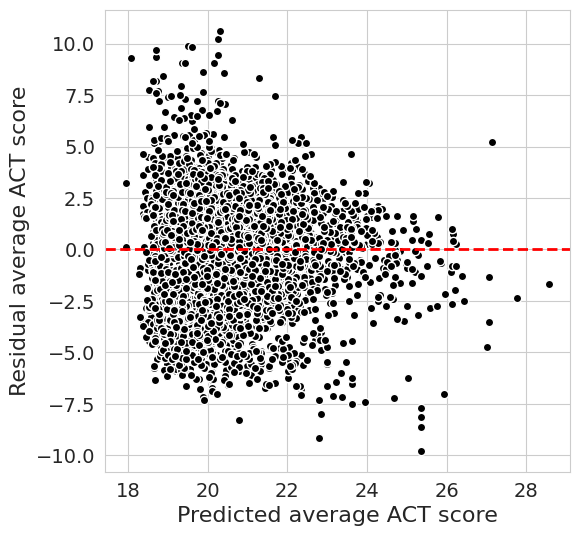

In [15]:
# Residual diagnostics: plot predicted ACT vs. residuals
# Look for random scatter around 0
plt.figure(figsize=(6, 6))

plt.plot(y_hat, model_median_income.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted average ACT score', fontsize=16)
plt.ylabel('Residual average ACT score', fontsize=16)

plt.tick_params(labelsize=14)

plt.show()

#### Try a quadratic model. Plot the regression curves and the scatter plot

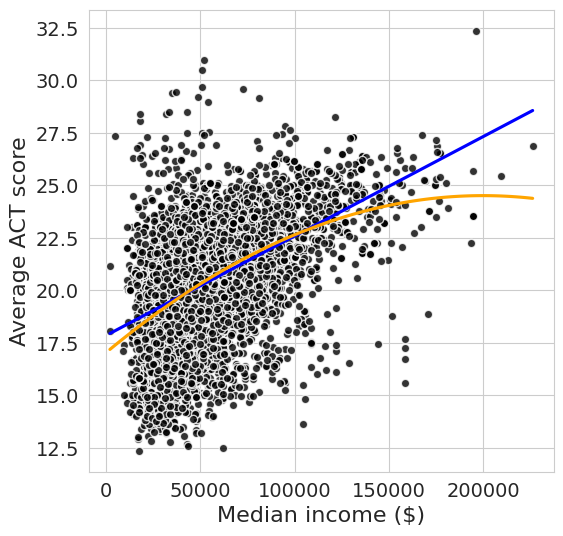

In [16]:
# Compare linear vs. quadratic fits for ACT and median_income
# -First regplot: straight OLS line (blue)
# -Second regplot: 2nd-order polynomial curve (orange)

plt.figure(figsize=(6, 6))

sns.regplot(data=df,
            x='median_income',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

sns.regplot(data=df,
            x='median_income',
            y='average_act',
            order=2,
            color='orange',
            ci=False,
            scatter=False)

# Add axis labels
plt.xlabel('Median income ($)', fontsize=16)
plt.ylabel('Average ACT score', fontsize=16)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize=14)

plt.show()

#### Fit a quadratic linear regression model

In [17]:
# Fit a quadratic model for ACT vs. income
model_median_income2 = smf.ols(
    formula='average_act ~ median_income + I(median_income**2)',
    data=df).fit()

#### Display the fit summary

In [18]:
print(model_median_income2.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     1222.
Date:                Thu, 23 Oct 2025   Prob (F-statistic):               0.00
Time:                        04:29:34   Log-Likelihood:                -17948.
No. Observations:                8182   AIC:                         3.590e+04
Df Residuals:                    8179   BIC:                         3.592e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                17.03

#### Assess the model significance

In [19]:
# Term-wise significance for the quadratic model
model_median_income2.pvalues

,0
Intercept,0.000000e+00
median_income,3.488096e-114
I(median_income ** 2),8.577586e-19


In [20]:
# Model comparison linear vs. quadratic.
anova_lm(model_median_income, model_median_income2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,8180.0,38889.790337,0.0,NaN,NaN,NaN
1,8179.0,38518.947517,1.0,370.84282,78.743674,8.577586e-19


#### Assess the model accuracy

Compute the mean absolute error

In [21]:
# MAE for the quadratic model, average absolute error
mean_absolute_error(df['average_act'], model_median_income2.predict())

1.6613007707431147

#### Compare the quadratic model accuracy to the first order model

In [22]:
# Compare accuracy: compute Mean Absolute Error for
# the quadratic model vs. the linear model (lower MAE = better fit).
mean_absolute_error(df['average_act'], model_median_income2.predict())

1.6613007707431147

In [23]:
mean_absolute_error(df['average_act'], model_median_income.predict())

1.6755079938705537

Marginal difference in MAE so stick to simpler model

### Unemployment rate

#### Plot the regression line and scatter plot

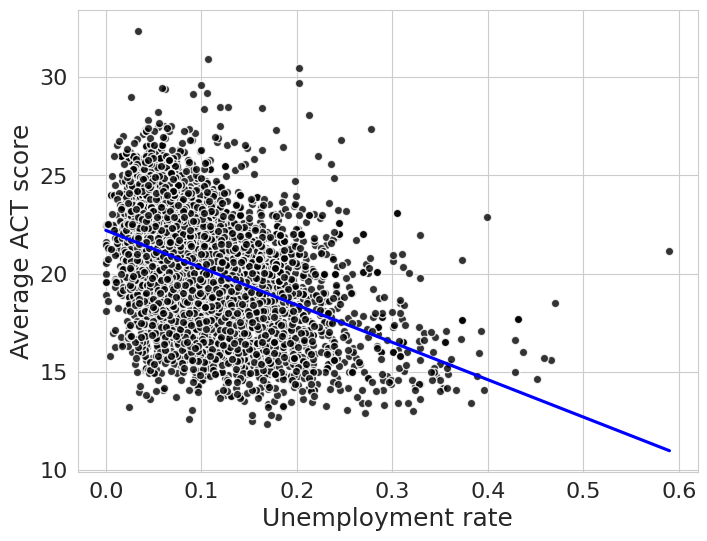

In [24]:
# Simple linear relationship: ACT vs. unemployment rate
plt.figure(figsize=(8, 6))

sns.regplot(data=df,
            x='rate_unemployment',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1}
)

# Add axis labels
plt.xlabel('Unemployment rate', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16)

plt.show()

#### Fit the simple linear regression model

In [25]:
# Fit a simple model: predict average ACT from unemployment rate
model_ru = smf.ols(formula='average_act ~ rate_unemployment', data=df).fit()

#### Display the fit summary: check sign and significance of the coefficients

In [26]:
print(model_ru.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     1903.
Date:                Thu, 23 Oct 2025   Prob (F-statistic):               0.00
Time:                        04:29:35   Log-Likelihood:                -18161.
No. Observations:                8182   AIC:                         3.633e+04
Df Residuals:                    8180   BIC:                         3.634e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.2023      0.04

The model is significant, but it is not great. The  R2=0.19 , which is low.

Make a residual plot to assess the model.

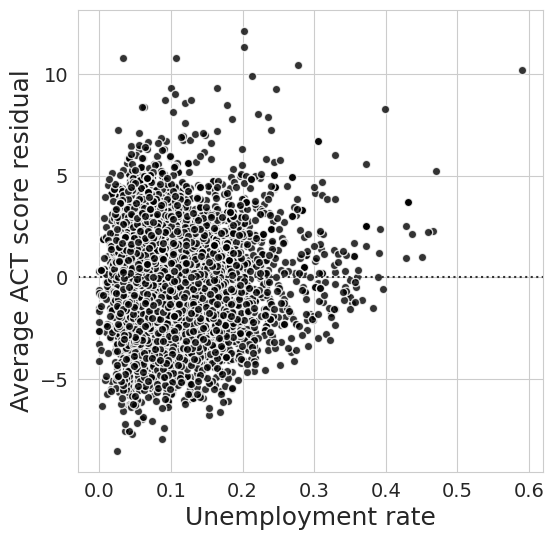

In [27]:
# Plot residuals from a fit of average_act on rate_unemployment.
# Each point = observed y minus fitted y at that x; a random band around 0 suggests
# linearity and constant variance
plt.figure(figsize=(6,6))

# residual plot
sns.residplot(data=df,
              x = 'rate_unemployment',
              y = 'average_act',
              scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Unemployment rate', fontsize = 18)
plt.ylabel('Average ACT score residual', fontsize = 18)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize=14)

plt.show()

Test whether a quadratic model is better.

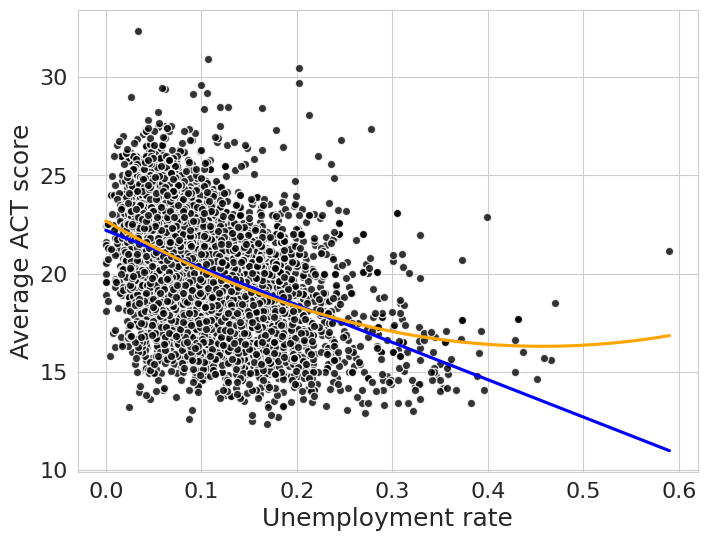

In [28]:
# Compare linear (blue) vs. quadratic (orange) fits for ACT ~ unemployment rate
plt.figure(figsize=(8,6))

sns.regplot(x='rate_unemployment',
            y='average_act',
            color='blue',
            data=df,
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

sns.regplot(x='rate_unemployment',
            y='average_act',
            color='orange',
            order = 2,
            data=df,
            ci=False,
            scatter=False)

# Add axis labels
plt.xlabel('Unemployment rate', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16)

plt.show()

In [61]:
# Fit a quadratic model for ACT vs. unemployment
# includes both the linear term (rate_unemployment) and its squared term
model_ru2 = smf.ols(formula='average_act ~ rate_unemployment + I(rate_unemployment**2)', data=df).fit()

In [30]:
print(model_ru2.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     991.8
Date:                Thu, 23 Oct 2025   Prob (F-statistic):               0.00
Time:                        04:29:37   Log-Likelihood:                -18129.
No. Observations:                8182   AIC:                         3.626e+04
Df Residuals:                    8179   BIC:                         3.628e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

A quadratic model is significant, but it does not improve the fit by much.

In [62]:
# Nested model ANOVA to see if adding the squared unemployment term improves fit
anova_lm(model_ru, model_ru2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,8180.0,40585.077718,0.0,NaN,NaN,NaN
1,8179.0,40260.678174,1.0,324.399544,65.902116,5.429339e-16


## Percent of students with free or reduced price lunch

#### Plot the regression line and scatter plot

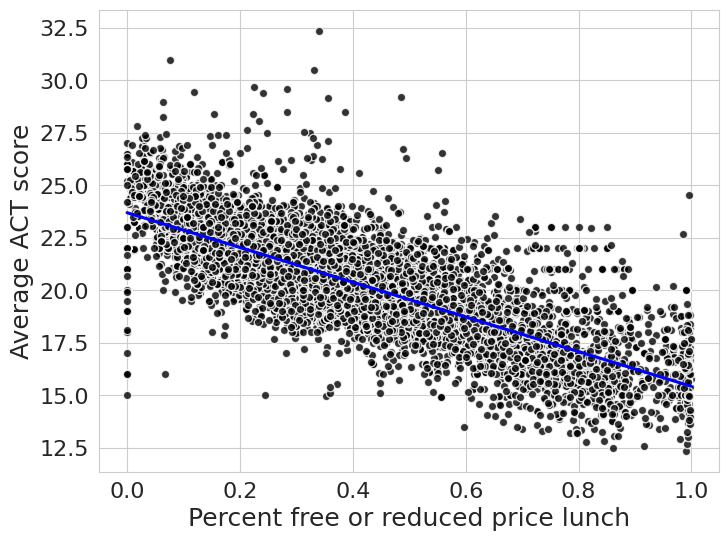

In [65]:
# Linear relationship: ACT vs. percent of students on free/reduced-price lunch
plt.figure(figsize=(8,6))

sns.regplot(data=df,
            x='percent_lunch',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Percent free or reduced price lunch', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16);

#### Fit the simple linear regression model, display the fit summary

check sign and significance of the coefficients

In [64]:
# Fit a simple model: Average ACT ~ Percent free/reduced-price lunch
model_pl = smf.ols(formula='average_act ~ percent_lunch', data=df).fit()

print(model_pl.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                 1.258e+04
Date:                Thu, 23 Oct 2025   Prob (F-statistic):               0.00
Time:                        04:47:13   Log-Likelihood:                -15206.
No. Observations:                8182   AIC:                         3.042e+04
Df Residuals:                    8180   BIC:                         3.043e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        23.6972      0.034    690.531

There is a strong negative linear relationship between the percent of students with free or reduced price lunch and the average ACT score ( R2=0.61 ).

Make a residual plot to assess the model

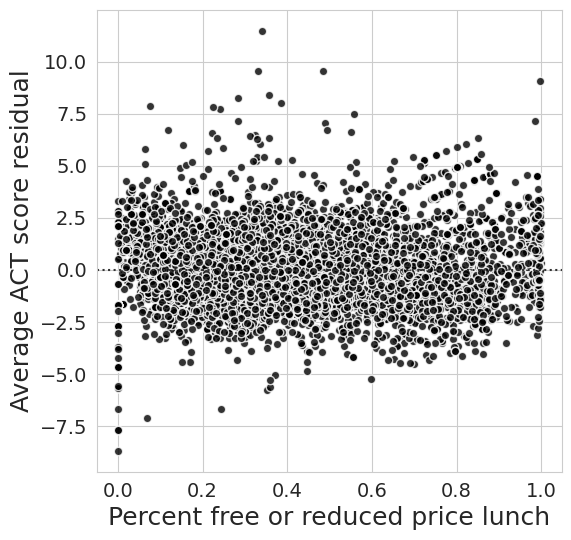

In [66]:
# Residual diagnostics for the model: plot residuals vs. percent_lunch.
plt.figure(figsize=(6,6))

# residual plot
sns.residplot(data=df,
              x = 'percent_lunch',
              y = 'average_act',
              scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})
# Add axis labels
plt.xlabel('Percent free or reduced price lunch', fontsize = 18)
plt.ylabel('Average ACT score residual', fontsize = 18)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize=14)

plt.show()

Test whether a quadratic model is better

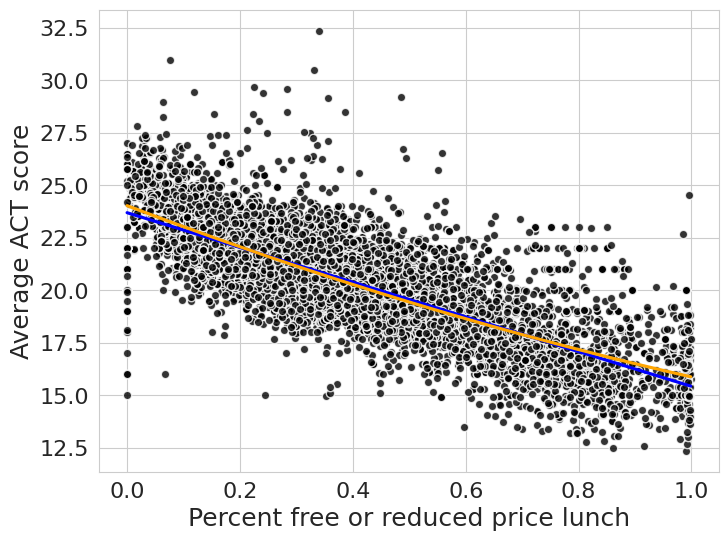

In [69]:
# Compare linear (blue) vs. quadratic (orange) fits for
# Average ACT ~ Percent free/reduced-price lunch
plt.figure(figsize=(8,6))

sns.regplot(x='percent_lunch',
            y='average_act',
            color='blue',
            data=df,
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

sns.regplot(x='percent_lunch',
            y='average_act',
            color='orange',
            order = 2,
            data=df,
            ci=False,
            scatter=False)

# Add axis labels
plt.xlabel('Percent free or reduced price lunch', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16)

plt.show()

In [70]:
# Fit a quadratic model: Average ACT ~ percent_lunch + (percent_lunch)^2
model_pl2 = smf.ols(formula='average_act ~ percent_lunch + I(percent_lunch**2)', data=df).fit()

In [71]:
print(model_pl2.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.609
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     6363.
Date:                Thu, 23 Oct 2025   Prob (F-statistic):               0.00
Time:                        04:49:21   Log-Likelihood:                -15178.
No. Observations:                8182   AIC:                         3.036e+04
Df Residuals:                    8179   BIC:                         3.038e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                24.03

A quadratic model is significant and does improve the fit but only slightly. Simpler model is about as accurate

In [72]:
# Nested-model ANOVA to see if adding (percent_lunch)^2 improves fit over the linear model
anova_lm(model_pl, model_pl2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,8180.0,19707.410213,0.0,NaN,NaN,NaN
1,8179.0,19571.539441,1.0,135.870772,56.780768,5.392700e-14


## Student Teacher Ratios

#### Plot the regression line and scatter plot

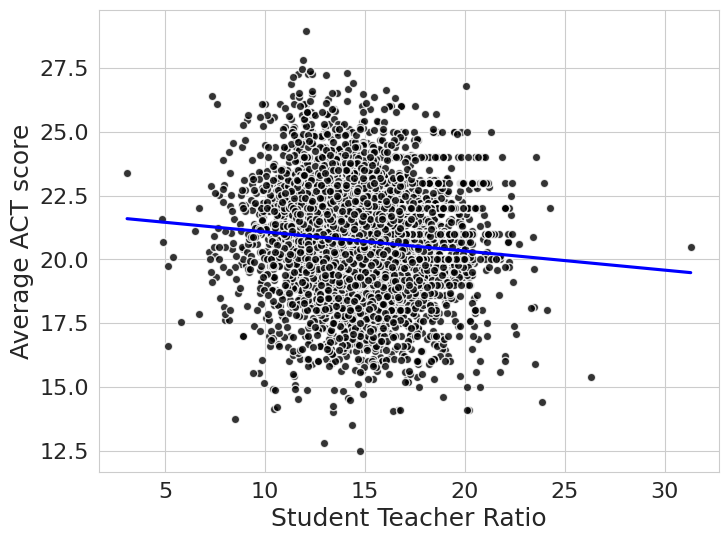

In [39]:
# Linear relationship: ACT vs. student–teacher ratio.
plt.figure(figsize=(8,6))

sns.regplot(data=df,
            x='student_teacher_ratio',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Student Teacher Ratio', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16);

#### Fit the simple linear regression model, display the fit summary

check sign and significance of the coefficients

In [73]:
# Fit a simple egression: predict average ACT from the student–teacher ratio
model_str = smf.ols(formula='average_act ~ student_teacher_ratio', data=df).fit()

print(model_str.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     50.30
Date:                Thu, 23 Oct 2025   Prob (F-statistic):           1.49e-12
Time:                        04:51:55   Log-Likelihood:                -11174.
No. Observations:                5219   AIC:                         2.235e+04
Df Residuals:                    5217   BIC:                         2.236e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                21.83

There is a very weak negative linear relationship between the student teacher ratio and the average ACT score (R2 = 0.006).

Make a residual plot to asses the model

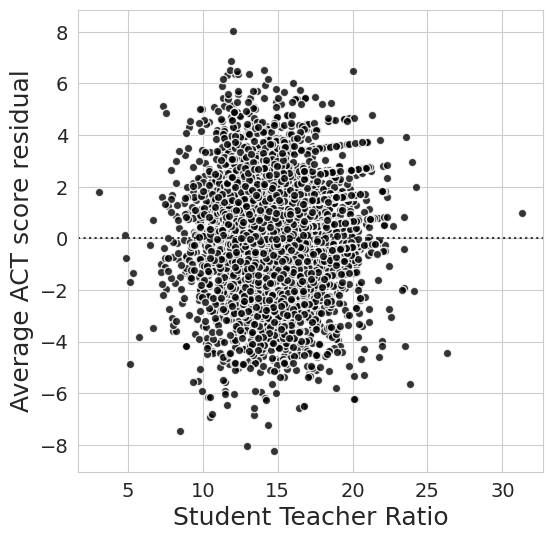

In [76]:
# Residual diagnostics for the student–teacher ratio model
plt.figure(figsize=(6,6))

# residual plot
sns.residplot(data=df,
              x = 'student_teacher_ratio',
              y = 'average_act',
              scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Student Teacher Ratio', fontsize = 18)
plt.ylabel('Average ACT score residual', fontsize = 18)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize=14)

plt.show()

Test whether a quadratic model is better

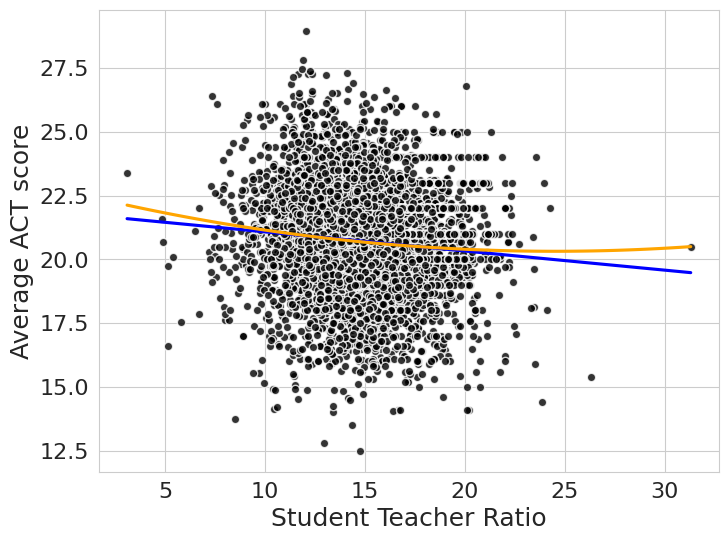

In [75]:
# Check if a quadratic curve captures the relationship better than a straight line
plt.figure(figsize=(8,6))

sns.regplot(x='student_teacher_ratio',
            y='average_act',
            color='blue',
            data=df,
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

sns.regplot(x='student_teacher_ratio',
            y='average_act',
            color='orange',
            order = 2,
            data=df,
            ci=False,
            scatter=False)
# Add axis labels
plt.xlabel('Student Teacher Ratio', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16)

plt.show()

In [74]:
# Fit a quadratic model for ACT ~ student_teacher_ratio
model_str2 = smf.ols(formula='average_act ~ student_teacher_ratio + I(student_teacher_ratio**2)', data=df).fit()

print(model_str2.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     26.39
Date:                Thu, 23 Oct 2025   Prob (F-statistic):           3.95e-12
Time:                        04:57:26   Log-Likelihood:                -11172.
No. Observations:                5219   AIC:                         2.235e+04
Df Residuals:                    5216   BIC:                         2.237e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

The quadratic model for student teacher ratio is statistically better, but the improvement is minimal and not very meaningful. The relationship between student teacher ratio and ACT scores is very weak whether modeled linearly or quadratically.

# Multiple linear regression

Fit the multiple liear regression model using all socioeconomic variables as predictors

In [44]:
model = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_married + median_income + percent_lunch',
    data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     2683.
Date:                Thu, 23 Oct 2025   Prob (F-statistic):               0.00
Time:                        04:29:42   Log-Likelihood:                -15044.
No. Observations:                8182   AIC:                         3.010e+04
Df Residuals:                    8176   BIC:                         3.014e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.5704      0.12

#### Use a residual plot for graphical assessment of model fit

In [45]:
y_hat = model.predict()

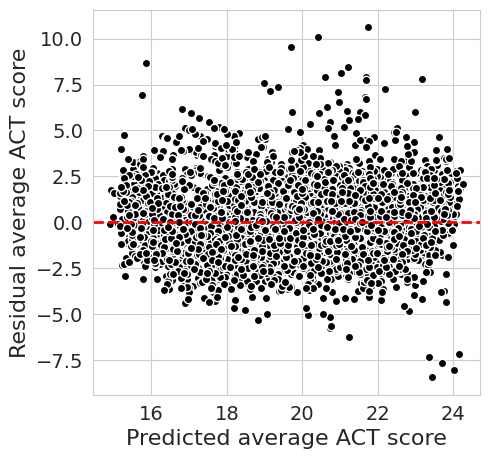

In [46]:
plt.figure(figsize=(5, 5))

plt.plot(y_hat, model.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted average ACT score', fontsize=16)
plt.ylabel('Residual average ACT score', fontsize=16)

plt.tick_params(labelsize=14)

plt.show()

#### Compute mean absolute error

In [47]:
mean_absolute_error(df['average_act'], model.predict())

1.140528694403699

## Summary

1. The multiple linear regression model with all socioeconomic predictors can predict ACT scores with an average error of roughly 1 point using these predictors.

2. The residual plot suggests that there will be limited improvement from adding transformations of these predictors.

3. Not all predictors have significant coefficients.

4. Adding predictors to the model may improve the performance.

# Fit a reduced model with the significant predictors

In [78]:
# Reduced multiple linear regression using only significant predictors identified earlier
# average_act ~ rate_unemployment + percent_college + percent_lunch
model_reduced = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_lunch',
    data=df).fit()

print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     4472.
Date:                Thu, 23 Oct 2025   Prob (F-statistic):               0.00
Time:                        05:03:58   Log-Likelihood:                -15045.
No. Observations:                8182   AIC:                         3.010e+04
Df Residuals:                    8178   BIC:                         3.013e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.5409      0.09

#### Use a residual plot for graphical assessment of model fit

In [79]:
# Get the fitted values from the reduced model to use in residual diagnostics
y_hat = model_reduced.predict()

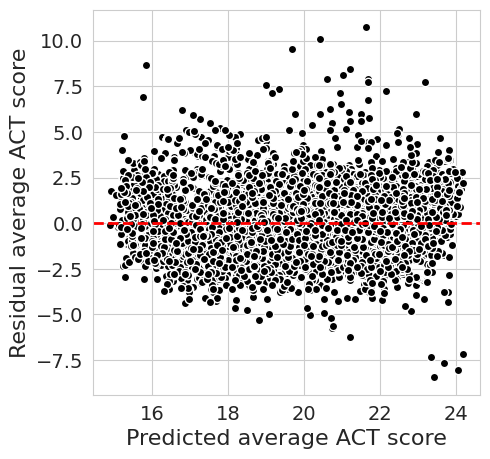

In [80]:
# Residuals vs. fitted plot for the reduced model:
# x = predicted ACT from model_reduced
# y = residuals (observed − fitted)
plt.figure(figsize=(5, 5))

plt.plot(y_hat, model_reduced.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted average ACT score', fontsize=16)
plt.ylabel('Residual average ACT score', fontsize=16)

plt.tick_params(labelsize=14)

plt.show()

#### Compute the mean absolute error

In [81]:
# In-sample Mean Absolute Error of the reduced model
mean_absolute_error(df['average_act'], model_reduced.predict())

1.1404343401395762

#### Compare the accuracy between full and reduced models



In [82]:
# Compare model accuracy: full vs. reduced
mae_full = mean_absolute_error(df['average_act'], model.predict())
mae_reduced = mean_absolute_error(df['average_act'], model_reduced.predict())

r2_full = model.rsquared
r2_reduced = model_reduced.rsquared

pd.DataFrame({'Mean Absolute Error': [mae_full, mae_reduced],
              'R-squared': [r2_full, r2_reduced]},
              index=['full model', 'reduced model']).round(4)

,Mean Absolute Error,R-squared
full model,1.1405,0.6213
reduced model,1.1404,0.6213


#### Use an ANOVA to test the significance of difference between models

In [83]:
# Nested-model ANOVA to test whether the full model improves fit over the reduced model.
anova_lm(model_reduced, model)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,8178.0,18946.202697,0.0,NaN,NaN,NaN
1,8176.0,18943.838872,2.0,2.363825,0.510103,0.600453


## Summary

1. The model predicting the average ACT score from `rate_unemployment`, `percent_college` and, `percent_lunch` is not significantly different than the model with all five socioeconomic variables as predictors.

2. Adding predictors to the model may improve the performance.

3. We have not yet determined the relative importance of each predictor in the model.

# Scaling

#### Scale the predictor variables in the reduced model to have mean 0 and standard deviation 1 and add them to the data frame

In [84]:
# Predictors to scale (those used in the reduced model)
predictor_variables = ['rate_unemployment', 'percent_college', 'percent_lunch']

In [55]:
# Create output column names for the standardized versions
scaled_columns = [var + '_normalized' for var in predictor_variables]

print(scaled_columns)

['rate_unemployment_normalized', 'percent_college_normalized', 'percent_lunch_normalized']


In [86]:
# Fit a StandardScaler on the selected predictors
scaler = StandardScaler().fit(df[predictor_variables])

In [57]:
# Transform and append the standardized features to the dataframe
df[scaled_columns] = scaler.transform(df[predictor_variables])

#### Check the mean and standard deviation of the transformed data.

In [87]:
# Verify the standardized features have mean = 0 and std = 1
df[scaled_columns].agg(['mean', 'std']).round(3)

,rate_unemployment_normalized,percent_college_normalized,percent_lunch_normalized
mean,-0.0,0.0,0.0
std,1.0,1.0,1.0


#### Fit the multiple linear regression model with the normalized predictors

In [88]:
# Multiple linear regression using the standardized predictors
# Coefficients are now on the same scale so magnitudes are comparable
model_normalized = smf.ols(
    formula='average_act ~ rate_unemployment_normalized + percent_college_normalized + percent_lunch_normalized',
    data=df).fit()

print(model_normalized.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     4472.
Date:                Thu, 23 Oct 2025   Prob (F-statistic):               0.00
Time:                        05:12:56   Log-Likelihood:                -15045.
No. Observations:                8182   AIC:                         3.010e+04
Df Residuals:                    8178   BIC:                         3.013e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

#### Compare the accuracy between the original and normalized models

In [89]:
# Compare performance of the normalized model vs. the original reduced model
# In-sample MAE
mae_normalized = mean_absolute_error(df['average_act'], model_normalized.predict())
mae_reduced = mean_absolute_error(df['average_act'], model_reduced.predict())

# R-squared
r2_normalized = model_normalized.rsquared
r2_reduced = model_reduced.rsquared

# Side-by-side summary
pd.DataFrame({'Mean Absolute Error': [mae_normalized, mae_reduced],
              'R-squared': [r2_normalized, r2_reduced]},
              index=['normalized model', 'reduced model']).round(4)

,Mean Absolute Error,R-squared
normalized model,1.1404,0.6213
reduced model,1.1404,0.6213


#### Summary

The percent of students at a school receiving free or reduced price lunch was the strongest predictor in this analysis